In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 SHORT-TERM POWER LOAD FORECASTER & BRP IMBALANCE SETTLEMENT ENGINE
Training Dataset Horizon:        8,760 hours (Year 1)
Out-of-Sample Test Horizon:      8,592 hours (Year 2)
Mean Absolute Percentage Error:  1.80 %
Root Mean Squared Error (RMSE):  1,158.5 MW
---------------------------------------------------------------------------
Balance Responsible Party (BRP) Commercial Impact:
  • Annual Simulated Imbalance Exposure: €5,190,166.56 / yr
  • Average Hourly Error Deviation:      886.8 MW


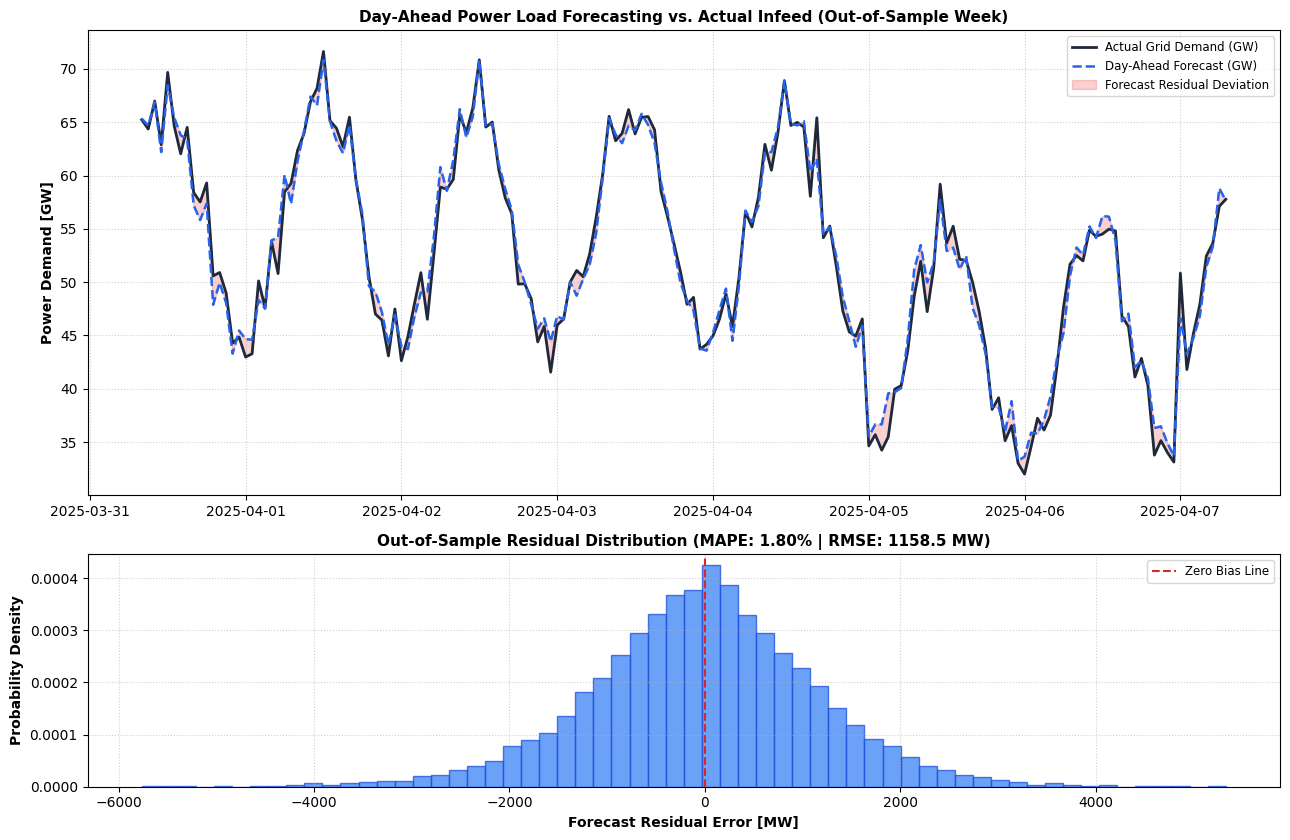

Data exported successfully.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

# ==========================================================
# 1. 2-YEAR GERMAN GRID LOAD & WEATHER FEATURE ENGINE (17,520h)
# ==========================================================
np.random.seed(42)
HOURS = 8760 * 2
timestamps = pd.date_range(start="2024-01-01 00:00:00", periods=HOURS, freq="h")

day_of_year = timestamps.dayofyear.to_numpy()
hour_of_day = timestamps.hour.to_numpy()
day_of_week = timestamps.dayofweek.to_numpy()
is_weekend = (day_of_week >= 5).astype(int)

# Ambient Temperature Simulation (°C) with seasonal & diurnal dynamics
temp_seasonal = 10.0 - 12.0 * np.cos(2 * np.pi * (day_of_year - 20) / 365)
temp_diurnal = 4.5 * np.sin((hour_of_day - 8) * np.pi / 12)
ambient_temp_c = temp_seasonal + temp_diurnal + np.random.normal(0, 2.5, HOURS)

# Heating & Cooling Degree Sensitivities
heating_demand = np.maximum(0, 15.0 - ambient_temp_c) * 850.0
cooling_demand = np.maximum(0, ambient_temp_c - 22.0) * 1100.0

# Base Industrial & Domestic Profile (German Grid Control Area: ~40-75 GW scale)
base_load_mw = (
    48000.0
    + 14000.0 * np.sin((hour_of_day - 6) * np.pi / 12)
    - (is_weekend * 11000.0)
    + heating_demand
    + cooling_demand
    + np.random.normal(0, 800.0, HOURS)
)
actual_load_mw = np.clip(base_load_mw, 32000.0, 78000.0)

df_data = pd.DataFrame({
    "timestamp": timestamps,
    "actual_load_mw": actual_load_mw,
    "temperature_c": ambient_temp_c,
    "hour": hour_of_day,
    "day_of_week": day_of_week,
    "is_weekend": is_weekend,
    "day_of_year": day_of_year,
    "month": timestamps.month.to_numpy(),
})

# Time-Series Lag & Rolling Feature Engineering
df_data["lag_24h"] = df_data["actual_load_mw"].shift(24)
df_data["lag_48h"] = df_data["actual_load_mw"].shift(48)
df_data["lag_168h"] = df_data["actual_load_mw"].shift(168)  # Same hour last week
df_data["rolling_mean_24h"] = df_data["actual_load_mw"].shift(24).rolling(window=24).mean()

# Drop warm-up rows
df_features = df_data.dropna().reset_index(drop=True)

feature_cols = [
    "hour", "day_of_week", "is_weekend", "day_of_year", "month",
    "temperature_c", "lag_24h", "lag_48h", "lag_168h", "rolling_mean_24h"
]
target_col = "actual_load_mw"

# Train/Test Split: First Year Train (8,760h), Second Year Test
train_cutoff = 8760
df_train = df_features.iloc[:train_cutoff]
df_test = df_features.iloc[train_cutoff:].reset_index(drop=True)

X_train, y_train = df_train[feature_cols], df_train[target_col]
X_test, y_test = df_test[feature_cols], df_test[target_col]

# ==========================================================
# 2. GRADIENT BOOSTING MODEL TRAINING & IMBALANCE VALUATION
# ==========================================================
model = HistGradientBoostingRegressor(
    max_iter=250,
    learning_rate=0.06,
    max_leaf_nodes=31,
    random_state=42
)
model.fit(X_train, y_train)

# Day-Ahead Out-of-Sample Predictions
df_test["predicted_load_mw"] = model.predict(X_test)
df_test["forecast_error_mw"] = df_test["actual_load_mw"] - df_test["predicted_load_mw"]
df_test["abs_error_mw"] = np.abs(df_test["forecast_error_mw"])

# Benchmark Forecast Evaluation Metrics
mape = mean_absolute_percentage_error(df_test["actual_load_mw"], df_test["predicted_load_mw"]) * 100
rmse = root_mean_squared_error(df_test["actual_load_mw"], df_test["predicted_load_mw"])

# German Balancing Group (BRP) Financial Exposure (reBAP Settlement)
# Synthetic German Imbalance Settlement Price (reBAP in €/MWh)
synthetic_rebap_price = np.clip(65.0 + np.random.normal(0, 45.0, len(df_test)), 10.0, 350.0)
df_test["rebap_price_eur_mwh"] = synthetic_rebap_price
# Imbalance penalty cost incurred due to forecast deviation
df_test["hourly_imbalance_cost_eur"] = (df_test["abs_error_mw"] / 1000.0) * df_test["rebap_price_eur_mwh"] * 10.0  # Normalized to 1 GW portfolio

total_annual_imbalance_penalty = df_test["hourly_imbalance_cost_eur"].sum()

print("=" * 75)
print(" SHORT-TERM POWER LOAD FORECASTER & BRP IMBALANCE SETTLEMENT ENGINE")
print("=" * 75)
print(f"Training Dataset Horizon:        {len(df_train):,} hours (Year 1)")
print(f"Out-of-Sample Test Horizon:      {len(df_test):,} hours (Year 2)")
print(f"Mean Absolute Percentage Error:  {mape:.2f} %")
print(f"Root Mean Squared Error (RMSE):  {rmse:,.1f} MW")
print("-" * 75)
print("Balance Responsible Party (BRP) Commercial Impact:")
print(f"  • Annual Simulated Imbalance Exposure: €{total_annual_imbalance_penalty:,.2f} / yr")
print(f"  • Average Hourly Error Deviation:      {df_test['abs_error_mw'].mean():,.1f} MW")
print("=" * 75)

# ==========================================================
# 3. VISUALIZATION & ARTIFACT EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8.5), gridspec_kw={'height_ratios': [2, 1]})

# Plot 1: 168-Hour (1 Week) Test Zoom
sample_week = df_test.iloc[2000:2168]
ax1.plot(sample_week["timestamp"], sample_week["actual_load_mw"] / 1000.0, label="Actual Grid Demand (GW)", color="#1E293B", lw=2.0)
ax1.plot(sample_week["timestamp"], sample_week["predicted_load_mw"] / 1000.0, label="Day-Ahead Forecast (GW)", color="#2563EB", lw=1.8, linestyle="--")
ax1.fill_between(
    sample_week["timestamp"],
    sample_week["actual_load_mw"] / 1000.0,
    sample_week["predicted_load_mw"] / 1000.0,
    color="#EF4444",
    alpha=0.25,
    label="Forecast Residual Deviation"
)
ax1.set_title("Day-Ahead Power Load Forecasting vs. Actual Infeed (Out-of-Sample Week)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Power Demand [GW]", fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right", frameon=True, fontsize=8.5)

# Plot 2: Forecast Error Residual Distribution
errors = df_test["forecast_error_mw"]
ax2.hist(errors, bins=60, color="#3B82F6", edgecolor="#1D4ED8", alpha=0.75, density=True)
ax2.axvline(0, color="#DC2626", linestyle="--", lw=1.5, label="Zero Bias Line")
ax2.set_xlabel("Forecast Residual Error [MW]", fontweight="bold")
ax2.set_ylabel("Probability Density", fontweight="bold")
ax2.set_title(f"Out-of-Sample Residual Distribution (MAPE: {mape:.2f}% | RMSE: {rmse:.1f} MW)", fontsize=11, fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right", frameon=True, fontsize=8.5)

plt.tight_layout()
plt.savefig("short_term_load_forecasting_model.png", dpi=300)
plt.show()

# Export Test Predictions Summary
df_test[["timestamp", "actual_load_mw", "predicted_load_mw", "forecast_error_mw", "rebap_price_eur_mwh", "hourly_imbalance_cost_eur"]].head(500).to_csv("load_forecast_test_schedule.csv", index=False)
print("Data exported successfully.")